In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
data_df = pd.read_csv('data.csv', sep=';')
# data_df = data_df[data_df['reaction.time'] < 2000]
data_df.head()

,subject,group,sex,age,education.years,block,block.name,trial,response.correct,reaction.time,time1,time2
0,brodi01,hc,f,62,2,0,training.0,1,True,940,0,0
1,brodi01,hc,f,62,2,0,training.0,2,True,595,0,0
2,brodi01,hc,f,62,2,0,training.0,3,True,616,0,0
3,brodi01,hc,f,62,2,0,training.0,4,True,583,0,0
4,brodi01,hc,f,62,2,0,training.0,5,True,598,0,0


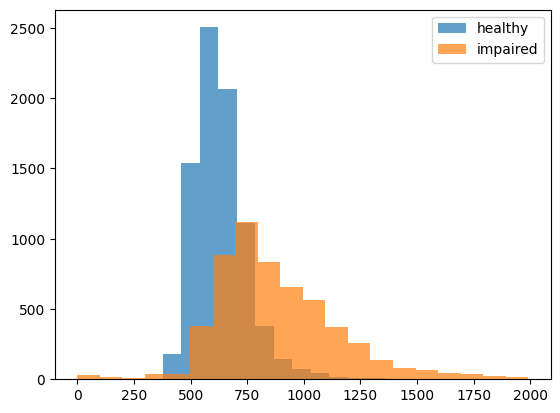

In [33]:
plt.hist(data_df[data_df['group'] == 'hc']['reaction.time'], bins=20, alpha=0.7, label='healthy')
plt.hist(data_df[data_df['group'] == 'ci']['reaction.time'], bins=20, alpha=0.7, label='impaired')
plt.legend()
plt.show()

In [59]:
data_df.groupby(['group', 'response.correct']).count()

subject   sex   age  education.years  block  \
group response.correct                                                
ci    False                 243   243   243              243    243   
      True                 5457  5457  5457             5457   5457   
hc    False                  16    16    16               16     16   
      True                 8084  8084  8084             8084   8084   

                        block.name  trial  reaction.time  time1  time2  
group response.correct                                                  
ci    False                    243    243            243    243    243  
      True                    5457   5457           5457   5457   5457  
hc    False                     16     16             16     16     16  
      True                    8084   8084           8084   8084   8084

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data
X = data_df[['age', 'reaction.time']]
y = data_df['group']

# Check for missing values
print("Missing values:")
print(X.isnull().sum())
print(f"\nClass distribution:\n{y.value_counts()}")

# Handle any missing values if present
X = X.dropna()
y = y[X.index]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features (important for logistic regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try multiple classifiers
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    
    # Use scaled data for LR and SVM, original for RF
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    auc = roc_auc_score(y_test, y_proba)
    print(f"\nAUC-ROC: {auc:.3f}")
    
    # Cross-validation
    if name == 'Random Forest':
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    else:
        cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='accuracy')
    print(f"Cross-validation accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    
    results[name] = {'model': model, 'auc': auc}

# Feature importance for Random Forest
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    importance = pd.DataFrame({
        'feature': ['age', 'reaction.time'],
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\n\nRandom Forest Feature Importance:")
    print(importance)

# Visualize decision boundary (for 2D case)
plt.figure(figsize=(12, 4))
for idx, (name, info) in enumerate(results.items(), 1):
    plt.subplot(1, 3, idx)
    model = info['model']
    
    # Create mesh
    h = 0.02
    x_min, x_max = X['age'].min() - 1, X['age'].max() + 1
    y_min, y_max = X['reaction.time'].min() - 1, X['reaction.time'].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict on mesh
    if name == 'Random Forest':
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    else:
        mesh_scaled = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
        Z = model.predict(mesh_scaled)
    
    # Convert string labels to numeric for plotting
    Z_numeric = (Z == 'ci').astype(int)
    Z_numeric = Z_numeric.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z_numeric, alpha=0.3, cmap='RdYlBu')
    
    # Plot points
    scatter = plt.scatter(X['age'], X['reaction.time'], 
                         c=(y == 'ci').astype(int), cmap='RdYlBu', 
                         edgecolors='black', alpha=0.6)
    plt.xlabel('Age')
    plt.ylabel('Reaction Time')
    plt.title(f'{name}\n(AUC: {info["auc"]:.3f})')
    plt.colorbar(scatter, label='Group (0=hc, 1=ci)')

plt.tight_layout()
plt.show()

Missing values:
age              0
reaction.time    0
dtype: int64

Class distribution:
group
hc    8100
ci    5700
Name: count, dtype: int64

Logistic Regression

Classification Report:
              precision    recall  f1-score   support

          ci       0.77      0.70      0.73      1140
          hc       0.80      0.86      0.83      1620

    accuracy                           0.79      2760
   macro avg       0.79      0.78      0.78      2760
weighted avg       0.79      0.79      0.79      2760


Confusion Matrix:
[[ 795  345]
 [ 232 1388]]

AUC-ROC: 0.861
Cross-validation accuracy: 0.781 (+/- 0.013)

SVM

Classification Report:
              precision    recall  f1-score   support

          ci       0.85      0.72      0.78      1140
          hc       0.82      0.91      0.87      1620

    accuracy                           0.83      2760
   macro avg       0.84      0.82      0.82      2760
weighted avg       0.84      0.83      0.83      2760


Confusion Matrix:
[[ 8

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
